In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mssm.models import *
from mssmViz.plot import *
import matplotlib
import copy as copy
from matplotlib import font_manager
import dotenv
import os
from src.tweedielsr import Tweedie
dotenv.load_dotenv()

# Optionally load fonts (plots want "Source Sans 3")
font_path = os.getenv("font_path")
n_cores = int(os.getenv("n_cores"))

if font_path is not None:
    font_files = font_manager.findSystemFonts(fontpaths=font_path)
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)

# Some settings for plots
cmp = matplotlib.colormaps['RdYlBu_r']
plt.rcParams["font.family"] = "Source Sans 3"
plt.rcParams["font.weight"] = "semibold"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.titlesize"] = 9.5
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["figure.titlesize"] = 11
math_font_size = 8
math_font = 'cm'

seed = 42*3
np_gen = np.random.default_rng(seed)

size_conv = 2.54
single_width = 6/size_conv
double_width = 12/size_conv
full_width = 19/size_conv

## HSMM of Energy Prices

In [ ]:
# Load data
energy_dat = pd.read_csv("./data/energy.csv")

# Create pseudo dat for latent process model
d_dat = pd.DataFrame({"pseudo": np.arange(1)})

# Setup hsmm via mssm
o_family = GAUMLSS()
d_family = GAMMALS()
n_S = 2 # Number of latent states
M = 1 # Number of observed signals
D = 100 # Max duration assumed for latent states
starts_with_first = True # First state starts with first observation?
links = []
obs_families = []
obs_formulas = []
d_families = []
d_formulas = []
pars = 0

for j in range(n_S):
    obs_families.append([])

    for m in range(M):
        obs_families[-1].append(o_family)
        # Model of mean of obs model in state j and of signal m
        obs_formulas.append(Formula(lhs("Price"), [i(),f(["EurDol"])], data=energy_dat))

        # Model of scale parameter of obs model in state j and of signal m is the same
        obs_formulas.append(Formula(lhs("Price"), [i(),f(["EurDol"])], data=energy_dat))

        links.extend(o_family.links)
        pars += 2

for j in range(n_S * (1 if starts_with_first else 2)):
    d_families.append(d_family)

    # Model of mean of dur model in state j
    d_formulas.append(Formula(lhs("pseudo"), [i()], data=d_dat))

    # Model of scale parameter of dur model in state j
    d_formulas.append(Formula(lhs("pseudo"), [i()], data=d_dat))

    links.extend(d_family.links)
    pars += 2

# State transition probabilities and initial state durations can be fixed
pi = np.array([1, 0])
T = np.array([[0, 1], [1,0]])

# Initialize Family
fam = HSMMFamily(
    pars,
    links,
    n_S,
    obs_fams=obs_families,
    d_fams=d_families,
    sid=np.array([0]),
    tid=None,
    T=T,
    pi=pi,
    D=D,
    M=M,
    starts_with_first=starts_with_first,
    ends_with_last=True,
    ends_in_last=False,
    n_cores=1,
)

energy_model = GSMM([*obs_formulas,*d_formulas],fam)
energy_model.fit(n_cores=n_cores*2,
                 method='qEFS',
                 sample_hessian=False,
                 structured_qefs=False,
                 global_opt_qefs=True)


Fitting - Conv.: 6.76e+01:   1%|          | 2/200 [07:26<13:05:20, 237.98s/it]

/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:1198: UserWarning: Setting ``response_scale=True`` is usually only appropriate for GAMMs or GAMMLSS.
  warnings.warn(
/Users/joshmac/Documents/repos/mssm_tutorials/src/mssmViz/plot.py:1198: UserWarning: Setting ``response_scale=True`` is usually only appropriate for GAMMs or GAMMLSS.
  warnings.warn(


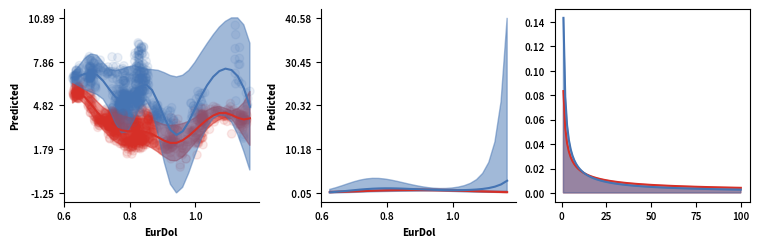

In [ ]:
fig = plt.figure(figsize=(full_width,single_width),layout='constrained')
axs = fig.subplots(1,3,gridspec_kw=dict(wspace=0.01,hspace=0.1))
viterbi = fam.decode_viterbi(energy_model.coef,energy_model.coef_split_idx,
                             energy_model.get_ys(),energy_model.get_mmat())

axs[0].scatter(energy_dat["EurDol"],energy_dat["Price"],
               c=[cmp(0.9) if s == 0 else cmp(0.1) for s in viterbi[0][1]],alpha=0.1)

pred_dat = pd.DataFrame({"EurDol":np.linspace(energy_dat["EurDol"].min(),
                                              energy_dat["EurDol"].max(),30)})

plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[0],response_scale=False,col=0.9,dist_par=0)
plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[0],response_scale=False,col=0.1,dist_par=2)

plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[1],response_scale=True,col=0.9,dist_par=1)
plot_fitted(pred_dat,["EurDol"],energy_model,ax=axs[1],response_scale=True,col=0.1,dist_par=3)

d_probs = fam.compute_od_probs(energy_model.coef,energy_model.coef_split_idx,
                               energy_model.get_ys(),energy_model.get_mmat(),
                               log=False)[0][1]
for si in range(2):
    
    pmf = d_probs[:,si]
    support = np.linspace(1,D,pmf.shape[0])

    axs[2].fill([*support,*np.flip(support)],
                [*pmf,*np.zeros_like(pmf)],
                color=(cmp(0.9) if si == 0 else cmp(0.1)),
                alpha=0.5)
    axs[2].plot(support,pmf,color=(cmp(0.9) if si == 0 else cmp(0.1)))


## Tweedie Location, scale, and shape model of Mackerel Egg data

In [2]:
# Load data
mackerel_dat = pd.read_csv("./data/mackerel.csv")

# Also coastline info for nicer plots
coast = pd.read_csv("./data/coast.csv")

# Create root and log variables
mackerel_dat["b.depth.r"] = np.sqrt(mackerel_dat["b.depth"].values)
mackerel_dat["log.vol"] = np.log(mackerel_dat["vol"].values)

# Handle nan's in predictors
nan_idx = np.any(np.isnan(mackerel_dat.loc[:,("T.20","Sal20")].values),axis=1)
mackerel_dat = mackerel_dat.loc[~nan_idx,:]

# Drop temperatures above 25 as done by Wood & Fasiolo
mackerel_dat = mackerel_dat.loc[mackerel_dat["T.20"].values < 25,:]

# Create model proposed by Wood & Fasiolo (2017)
# Replace Duchon spline with similarly complex tensor smooth
formula_mu = Formula(lhs("count"),[i(),l(["log.vol"]),f(["lo","la"],te=True,nk=12),
                                   f(["T.20"]),f(["Sal20"]),f(["b.depth.r"]),
                                   ri("ship")],data=mackerel_dat)

formula_theta = Formula(lhs("count"),[i(),f(["b.depth.r"])],data=mackerel_dat)

formula_rho = Formula(lhs("count"),[i(),f(["b.depth.r"])],data=mackerel_dat)

formulas = [formula_mu,formula_theta,formula_rho]

# Fit model via EFS
mackerel_model = GAMMLSS(formulas,Tweedie())
mackerel_model.fit()

# Get residuals and partial prediction for partial residual plot
res = mackerel_model.get_resid()
sal20_pred = mackerel_model.predict([4],mackerel_dat)[0]

Converged!:  17%|█▋        | 34/200 [00:56<04:35,  1.66s/it]                


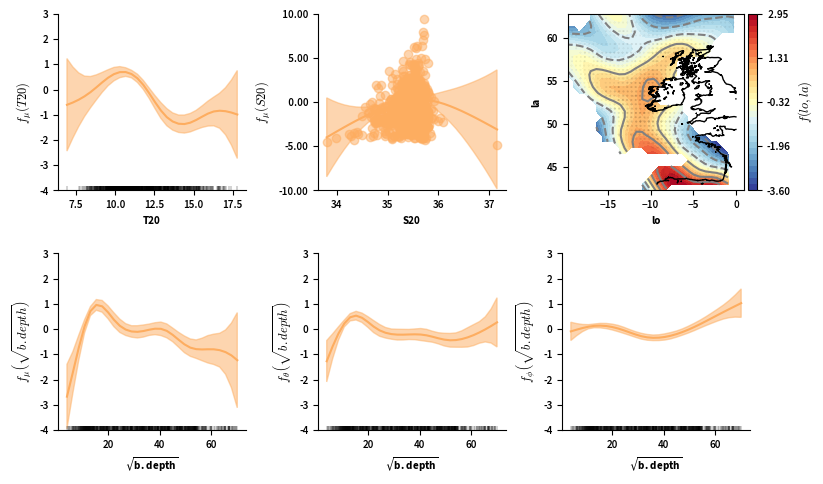

In [3]:
# Visualize EFS results
fig = plt.figure(figsize=(full_width,2*single_width),layout='constrained')
axs = fig.subplots(2,3,gridspec_kw=dict(wspace=0.01,hspace=0.1)).flatten()

plot(mackerel_model,dist_par=0,which=[3],axs=[axs[0]],plot_exist=True,ylim=[-4,3])

axs[1].scatter(mackerel_dat["Sal20"].values,sal20_pred.reshape(-1,1) + res,color=cmp(0.7),alpha=0.5)
plot(mackerel_model,dist_par=0,which=[4],axs=[axs[1]],plot_exist=False,ylim=[-10,10])


plot(mackerel_model,plot_exist=True,lim_dist=0.05,ci=False,which=[2],axs=[axs[2]])
axs[2].plot(coast["lon"].values,coast["lat"].values,color="black",linewidth=1)

plot(mackerel_model,dist_par=0,which=[5],axs=[axs[3]],plot_exist=True,ylim=[-4,3])
plot(mackerel_model,dist_par=1,axs=[axs[4]],plot_exist=True,ylim=[-4,3])
plot(mackerel_model,dist_par=2,axs=[axs[5]],plot_exist=True,ylim=[-4,3])

for axi in [0,3,4,5]:
    axs[axi].set_yticks([-4,-3,-2,-1,0,1,2,3],
                        [-4,-3,-2,-1,0,1,2,3])
    
axs[0].set_ylabel("$f_{\\mu}(T20)$")
axs[1].set_ylabel("$f_{\\mu}(S20)$")
axs[0].set_xlabel("T20",fontweight="bold")
axs[1].set_xlabel("S20",fontweight="bold")
axs[3].set_ylabel("$f_{\\mu}\\left(\\sqrt{b.depth}\\right)$")
axs[4].set_ylabel("$f_{\\theta}\\left(\\sqrt{b.depth}\\right)$")
axs[5].set_ylabel("$f_{\\phi}\\left(\\sqrt{b.depth}\\right)$")

axs[3].set_xlabel("$\\sqrt{\\regular{b.depth}}$",fontweight="bold")
axs[4].set_xlabel("$\\sqrt{\\regular{b.depth}}$",fontweight="bold")
axs[5].set_xlabel("$\\sqrt{\\regular{b.depth}}$",fontweight="bold")
plt.show()

In [ ]:
# Fit pqEEFS
mackerel_model2 = GSMM(formulas,GAMLSSGSMMFamily(3,mackerel_model.family))
mackerel_model2.fit(method='qEFS',structured_qefs=True,repara=True,
                    structured_qefs_budget=50,n_cores=1)

# Again get residuals and partial predictions
res2 = Tweedie().get_resid(mackerel_model2.get_ys()[0],*mackerel_model2.mus)
sal20_pred2 = mackerel_model2.predict([4],mackerel_dat)[0]

In [ ]:
# Visualize pqEFS results
fig = plt.figure(figsize=(full_width,2*single_width),layout='constrained')
axs = fig.subplots(2,3,gridspec_kw=dict(wspace=0.01,hspace=0.1)).flatten()

plot(mackerel_model2,dist_par=0,which=[3],axs=[axs[0]],plot_exist=True,ylim=[-4,3])

#axs[1].scatter(mackerel_dat["Sal20"].values,sal20_pred2.reshape(-1,1) + res2,color=cmp(0.7),alpha=0.5)
plot(mackerel_model,dist_par=0,which=[4],axs=[axs[1]],plot_exist=False,ylim=[-4,3],prov_cols=0.3)
plot(mackerel_model2,dist_par=0,which=[4],axs=[axs[1]],plot_exist=True,ylim=[-4,3])


plot(mackerel_model2,plot_exist=True,lim_dist=0.05,ci=False,which=[2],axs=[axs[2]])
axs[2].plot(coast["lon"].values,coast["lat"].values,color="black",linewidth=1)

plot(mackerel_model2,dist_par=0,which=[5],axs=[axs[3]],plot_exist=True,ylim=[-4,3])
plot(mackerel_model2,dist_par=1,axs=[axs[4]],plot_exist=True,ylim=[-4,3])
plot(mackerel_model2,dist_par=2,axs=[axs[5]],plot_exist=True,ylim=[-4,3])

for axi in [0,1,3,4,5]:
    axs[axi].set_yticks([-4,-3,-2,-1,0,1,2,3],
                        [-4,-3,-2,-1,0,1,2,3])
    
axs[0].set_ylabel("$f_{\\mu}(T20)$")
axs[1].set_ylabel("$f_{\\mu}(S20)$")
axs[0].set_xlabel("T20",fontweight="bold")
axs[1].set_xlabel("S20",fontweight="bold")
axs[3].set_ylabel("$f_{\\mu}\\left(\\sqrt{b.depth}\\right)$")
axs[4].set_ylabel("$f_{\\theta}\\left(\\sqrt{b.depth}\\right)$")
axs[5].set_ylabel("$f_{\\phi}\\left(\\sqrt{b.depth}\\right)$")

axs[3].set_xlabel("$\\sqrt{\\regular{b.depth}}$",fontweight="bold")
axs[4].set_xlabel("$\\sqrt{\\regular{b.depth}}$",fontweight="bold")
axs[5].set_xlabel("$\\sqrt{\\regular{b.depth}}$",fontweight="bold")
plt.savefig("./results/plots/mackerel.pdf", format="pdf", bbox_inches='tight')
plt.show()